E-COMMERCE SALES ANALYSIS PROJECT

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

LOAD DATASETS

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")

orders = pd.read_csv("olist_orders_dataset.csv")

order_items = pd.read_csv("olist_order_items_dataset.csv")

payments = pd.read_csv("olist_order_payments_dataset.csv")

reviews = pd.read_csv("olist_order_reviews_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

sellers = pd.read_csv("olist_sellers_dataset.csv")

category_translation = pd.read_csv(
    "product_category_name_translation.csv"
)

print("Customers :", customers.shape)
print("Orders :", orders.shape)
print("Order Items :", order_items.shape)
print("Payments :", payments.shape)
print("Reviews :", reviews.shape)
print("Products :", products.shape)
print("Sellers :", sellers.shape)

Customers : (99441, 5)
Orders : (99441, 8)
Order Items : (112650, 7)
Payments : (103886, 5)
Reviews : (99224, 7)
Products : (32951, 9)
Sellers : (3095, 4)


DATA CLEANING

In [3]:
datasets = [
    customers,
    orders,
    order_items,
    payments,
    reviews,
    products,
    sellers
]

for data in datasets:

    data.drop_duplicates(inplace=True)

print("Duplicates Removed")

# Missing Values

print(products.isnull().sum())

products['product_category_name'].fillna(
    "unknown",
    inplace=True
)


Duplicates Removed
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


DATE CONVERSION

In [4]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)



MERGE DATASETS

In [5]:
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

df = df.merge(
    order_items,
    on='order_id',
    how='left'
)

df = df.merge(
    payments,
    on='order_id',
    how='left'
)

df = df.merge(
    products,
    on='product_id',
    how='left'
)

df = df.merge(
    sellers,
    on='seller_id',
    how='left'
)

df = df.merge(
    reviews[['order_id','review_score']],
    on='order_id',
    how='left'
)

df = df.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

print(df.shape)



(119143, 35)


FEATURE ENGINEERING

In [6]:
df['Revenue'] = (
    df['price'] +
    df['freight_value']
)

df['Year'] = (
    df['order_purchase_timestamp']
    .dt.year
)

df['Month'] = (
    df['order_purchase_timestamp']
    .dt.month_name()
)

df['Month_Num'] = (
    df['order_purchase_timestamp']
    .dt.month
)

df['Day'] = (
    df['order_purchase_timestamp']
    .dt.day_name()
)

# Delivery Days

df['delivery_days'] = (
    df['order_delivered_customer_date']
    -
    df['order_purchase_timestamp']
).dt.days

# Delay Days

df['delay_days'] = (
    df['order_delivered_customer_date']
    -
    df['order_estimated_delivery_date']
).dt.days



KPI SECTION

In [7]:
total_revenue = round(
    df['Revenue'].sum(),2
)

total_orders = (
    df['order_id']
    .nunique()
)

total_customers = (
    df['customer_unique_id']
    .nunique()
)

avg_order_value = round(
    df.groupby('order_id')['Revenue']
      .sum()
      .mean(),2
)

avg_review = round(
    df['review_score']
      .mean(),2
)

print("="*50)

print("TOTAL REVENUE :", total_revenue)

print("TOTAL ORDERS :", total_orders)

print("TOTAL CUSTOMERS :", total_customers)

print("AVERAGE ORDER VALUE :", avg_order_value)

print("AVERAGE REVIEW SCORE :", avg_review)

print("="*50)


TOTAL REVENUE : 16643731.3
TOTAL ORDERS : 99441
TOTAL CUSTOMERS : 96096
AVERAGE ORDER VALUE : 167.37
AVERAGE REVIEW SCORE : 4.02


TOP PRODUCT CATEGORIES

In [8]:
top_categories = (
    df.groupby(
        'product_category_name_english'
    )['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_categories)


product_category_name_english
health_beauty            1491397.76
watches_gifts            1358845.59
bed_bath_table           1327662.02
sports_leisure           1205197.85
computers_accessories    1104362.03
furniture_decor           955367.22
housewares                823623.50
cool_stuff                752702.21
auto                      714431.95
garden_tools              625387.31
Name: Revenue, dtype: float64


MONTHLY SALES

In [9]:
monthly_sales = (
    df.groupby(
        'Month_Num'
    )['Revenue']
    .sum()
)

print(monthly_sales)



Month_Num
1     1306772.95
2     1342659.96
3     1668858.94
4     1650810.02
5     1827967.20
6     1606805.50
7     1729281.11
8     1744564.69
9      767846.91
10     867642.18
11    1232074.30
12     898447.54
Name: Revenue, dtype: float64


STATE SALES

In [10]:
state_sales = (
    df.groupby(
        'customer_state'
    )['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
)

print(state_sales.head())


customer_state
SP    6234533.82
RJ    2247128.32
MG    1928571.09
RS     934286.75
PR     832059.40
Name: Revenue, dtype: float64


REVIEW DISTRIBUTION

In [11]:
print(
    df['review_score']
    .value_counts()
)


review_score
5.0    66343
4.0    22319
1.0    15428
3.0     9894
2.0     4162
Name: count, dtype: int64


CUSTOMER SEGMENTATION

In [12]:
customer_revenue = (
    df.groupby(
        'customer_unique_id'
    )['Revenue']
    .sum()
)

segments = pd.qcut(
    customer_revenue,
    q=3,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value'
    ]
)

print(
    segments.value_counts()
)


Revenue
Medium Value    32047
Low Value       32036
High Value      32013
Name: count, dtype: int64


TOP SELLERS

In [13]:
top_sellers = (
    df.groupby(
        'seller_id'
    )['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_sellers)



seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    254387.70
4a3ca9315b744ce9f8e9374361493884    253535.64
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    198621.24
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    178696.05
7a67c85e85bb2ce8582c35f2203ad736    172887.23
955fee9216a65b617aa5c0531780ce60    163275.71
Name: Revenue, dtype: float64


PAYMENT ANALYSIS

In [ ]:
payment_analysis = (
    df.groupby(
        'payment_type'
    )['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
)

print(payment_analysis)


payment_type
credit_card    12776455.36
boleto          2859446.84
voucher          791647.56
debit_card       216038.08
not_defined           0.00
Name: Revenue, dtype: float64


ORDER STATUS ANALYSIS

In [ ]:
print(
    df['order_status']
    .value_counts()
)

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


DELIVERY ANALYSIS

In [16]:
print(
    "Average Delivery Days :",
    round(
        df['delivery_days']
        .mean(),
        2
    )
)

print(
    "Maximum Delivery Days :",
    df['delivery_days']
    .max()
)

print(
    "Minimum Delivery Days :",
    df['delivery_days']
    .min()
)


Average Delivery Days : 12.02
Maximum Delivery Days : 209.0
Minimum Delivery Days : 0.0


VISUALIZATION 1
# TOP CATEGORIES


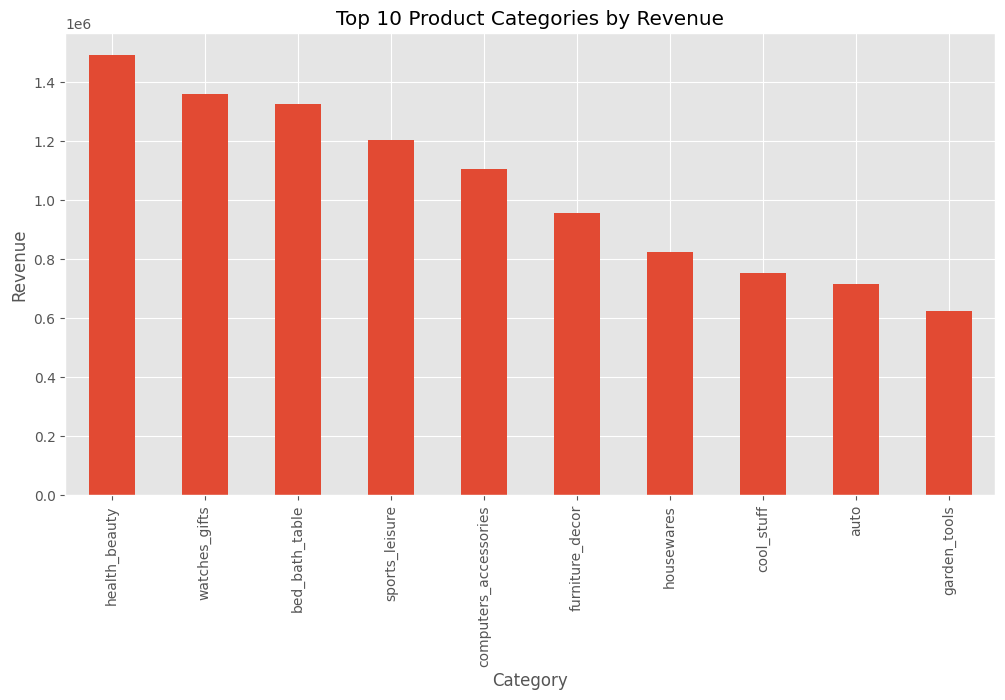

In [17]:
plt.figure(figsize=(12,6))

top_categories.plot(
    kind='bar'
)

plt.title(
    "Top 10 Product Categories by Revenue"
)

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()



VISUALIZATION 2
# MONTHLY SALES

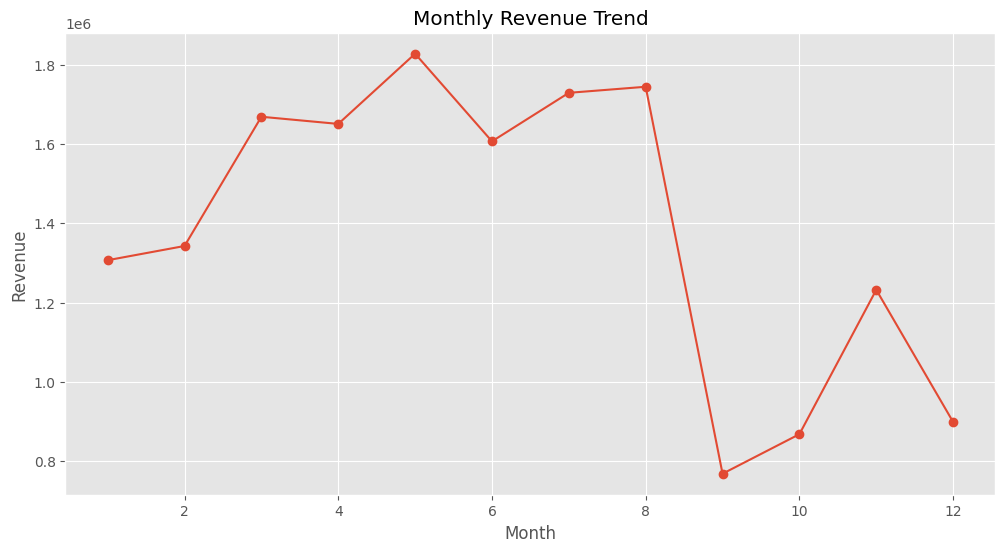

In [18]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()



VISUALIZATION 3
# STATE SALES

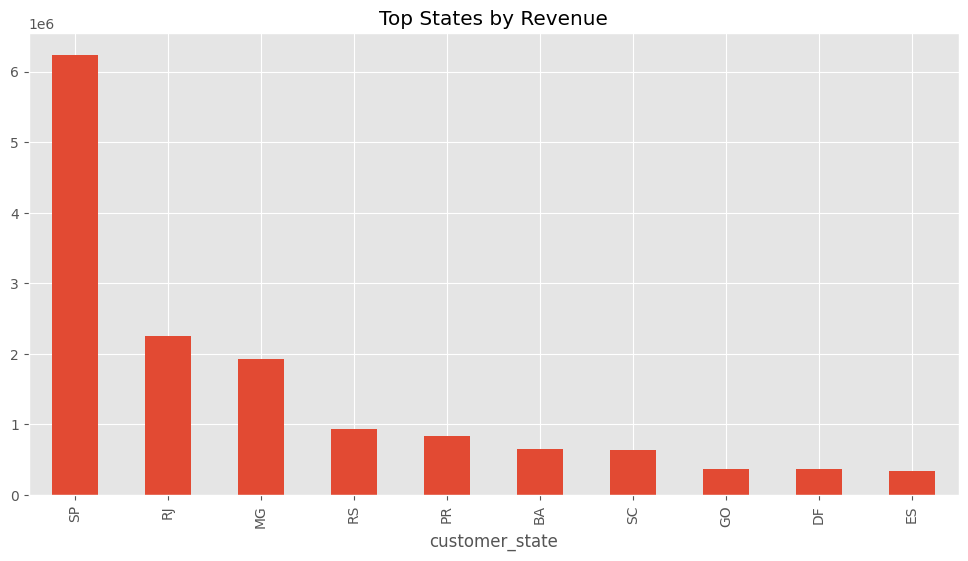

In [19]:
plt.figure(figsize=(12,6))

state_sales.head(10).plot(
    kind='bar'
)

plt.title(
    "Top States by Revenue"
)

plt.show()



VISUALIZATION 4
# REVIEW SCORE

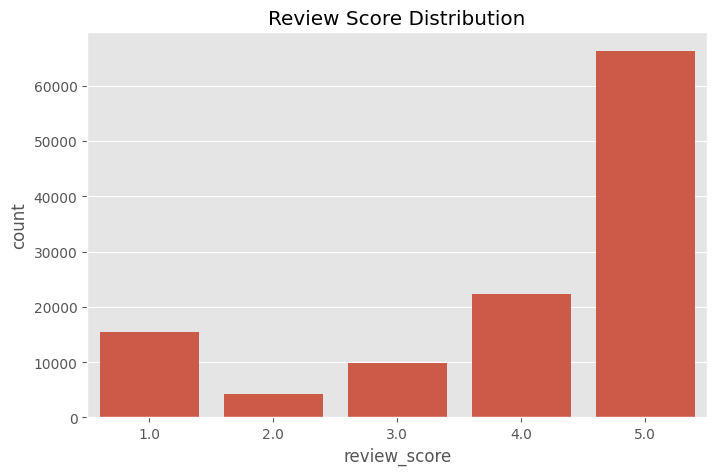

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=df
)

plt.title(
    "Review Score Distribution"
)

plt.show()



VISUALIZATION 5
# REVENUE DISTRIBUTION

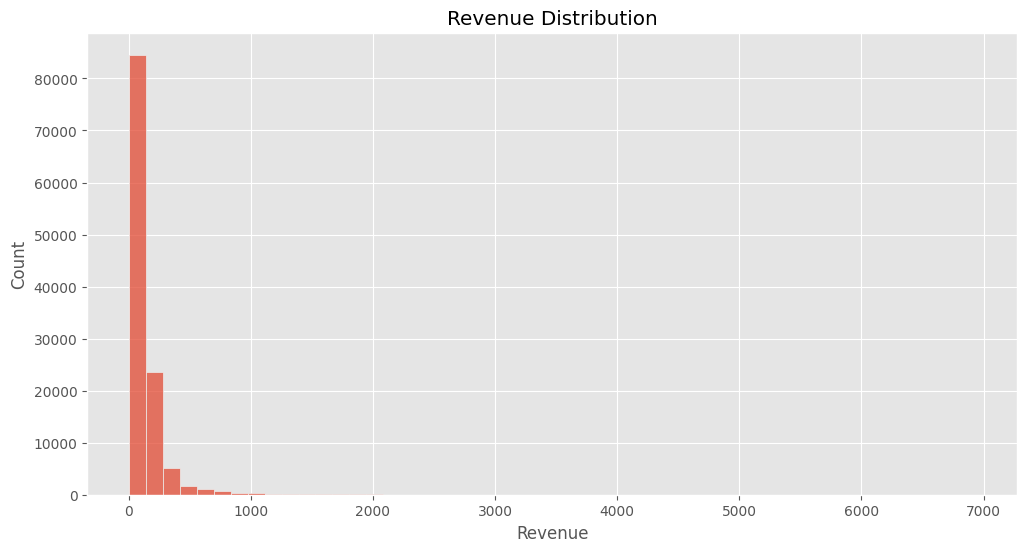

In [21]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['Revenue'],
    bins=50
)

plt.title(
    "Revenue Distribution"
)

plt.show()



VISUALIZATION 6
# PAYMENT TYPE

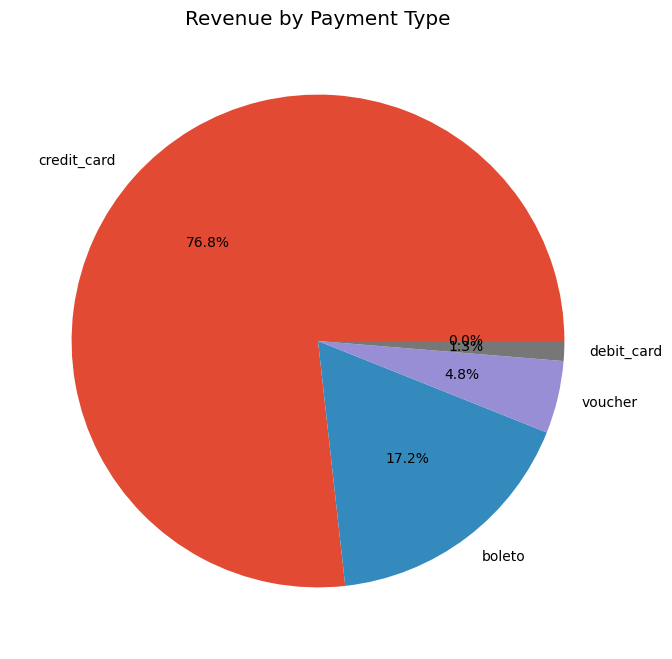

In [22]:
plt.figure(figsize=(8,8))

payment_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title(
    "Revenue by Payment Type"
)

plt.show()


VISUALIZATION 7
# TOP SELLERS

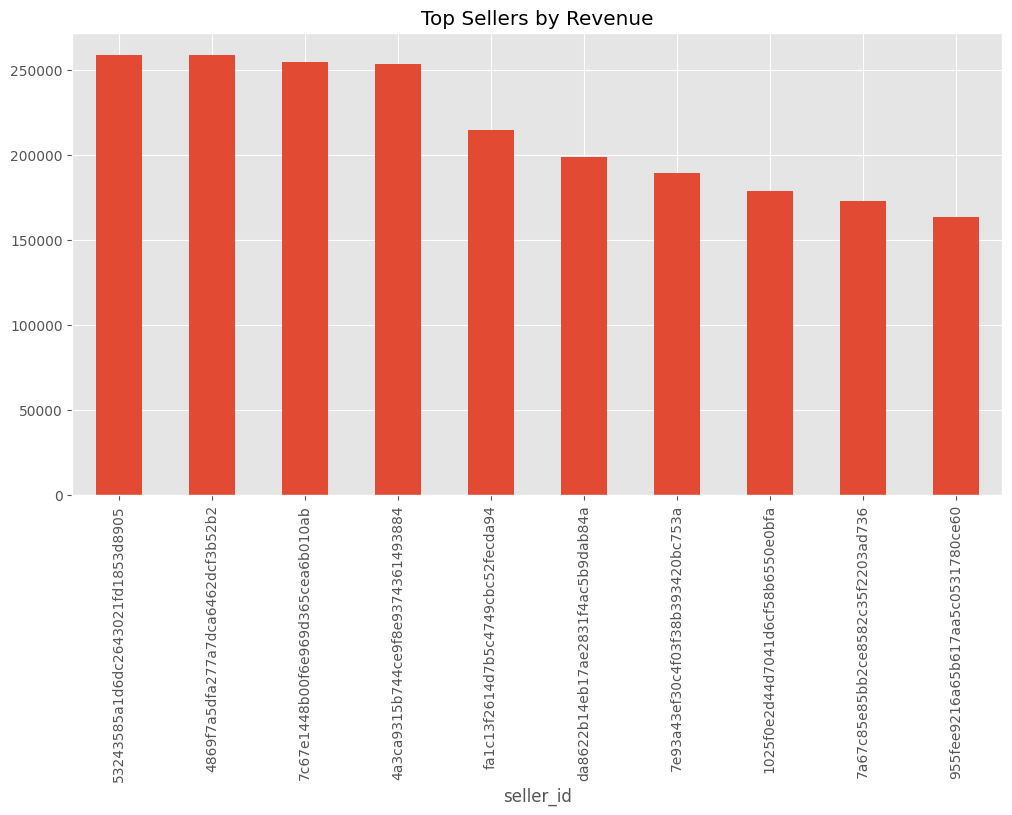

In [23]:
plt.figure(figsize=(12,6))

top_sellers.plot(
    kind='bar'
)

plt.title(
    "Top Sellers by Revenue"
)

plt.show()


VISUALIZATION 8
# ORDER STATUS

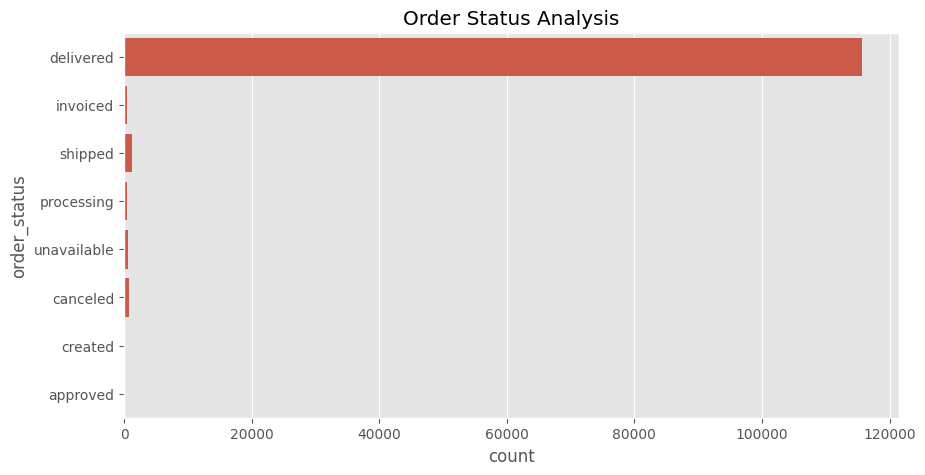

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='order_status',
    data=df
)

plt.title(
    "Order Status Analysis"
)

plt.show()



VISUALIZATION 9
# DELIVERY DAYS

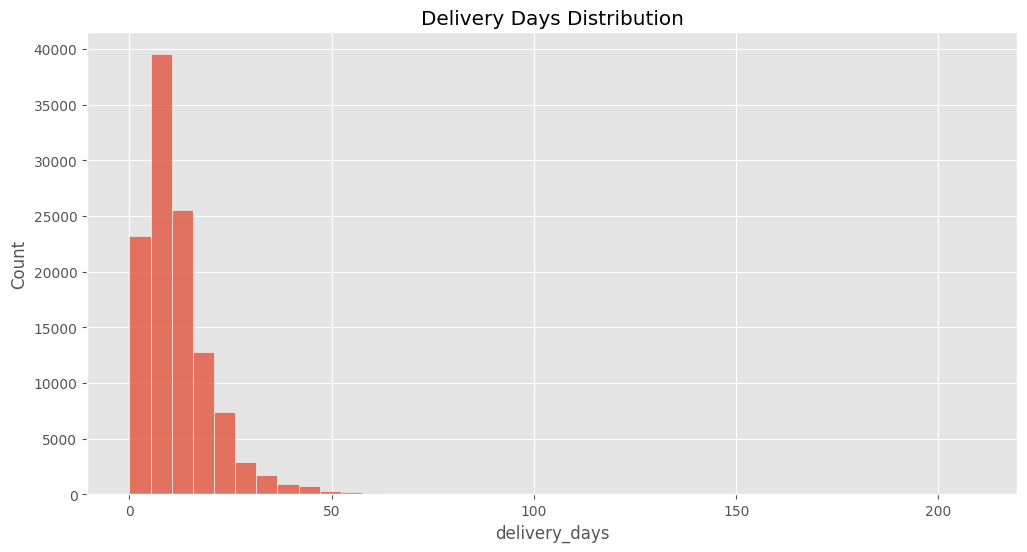

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['delivery_days'],
    bins=40
)

plt.title(
    "Delivery Days Distribution"
)

plt.show()


VISUALIZATION 10
# CUSTOMER SEGMENTS

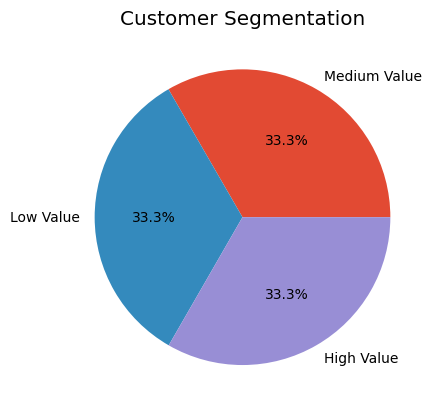

In [26]:
segments.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    "Customer Segmentation"
)

plt.ylabel("")

plt.show()


VISUALIZATION 11
# REVIEW VS REVENUE

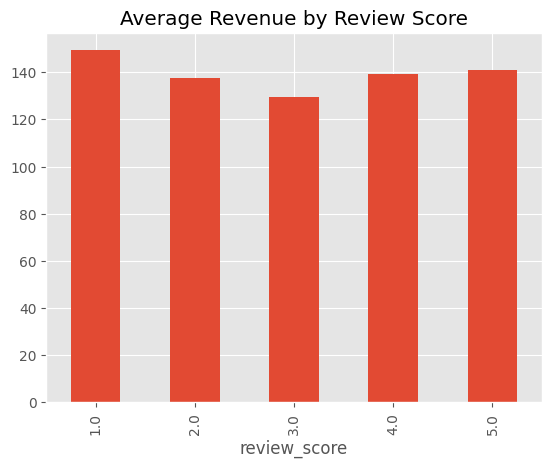

In [27]:
review_revenue = (
    df.groupby(
        'review_score'
    )['Revenue']
    .mean()
)

review_revenue.plot(
    kind='bar'
)

plt.title(
    "Average Revenue by Review Score"
)

plt.show()


VISUALIZATION 12
# HEATMAP

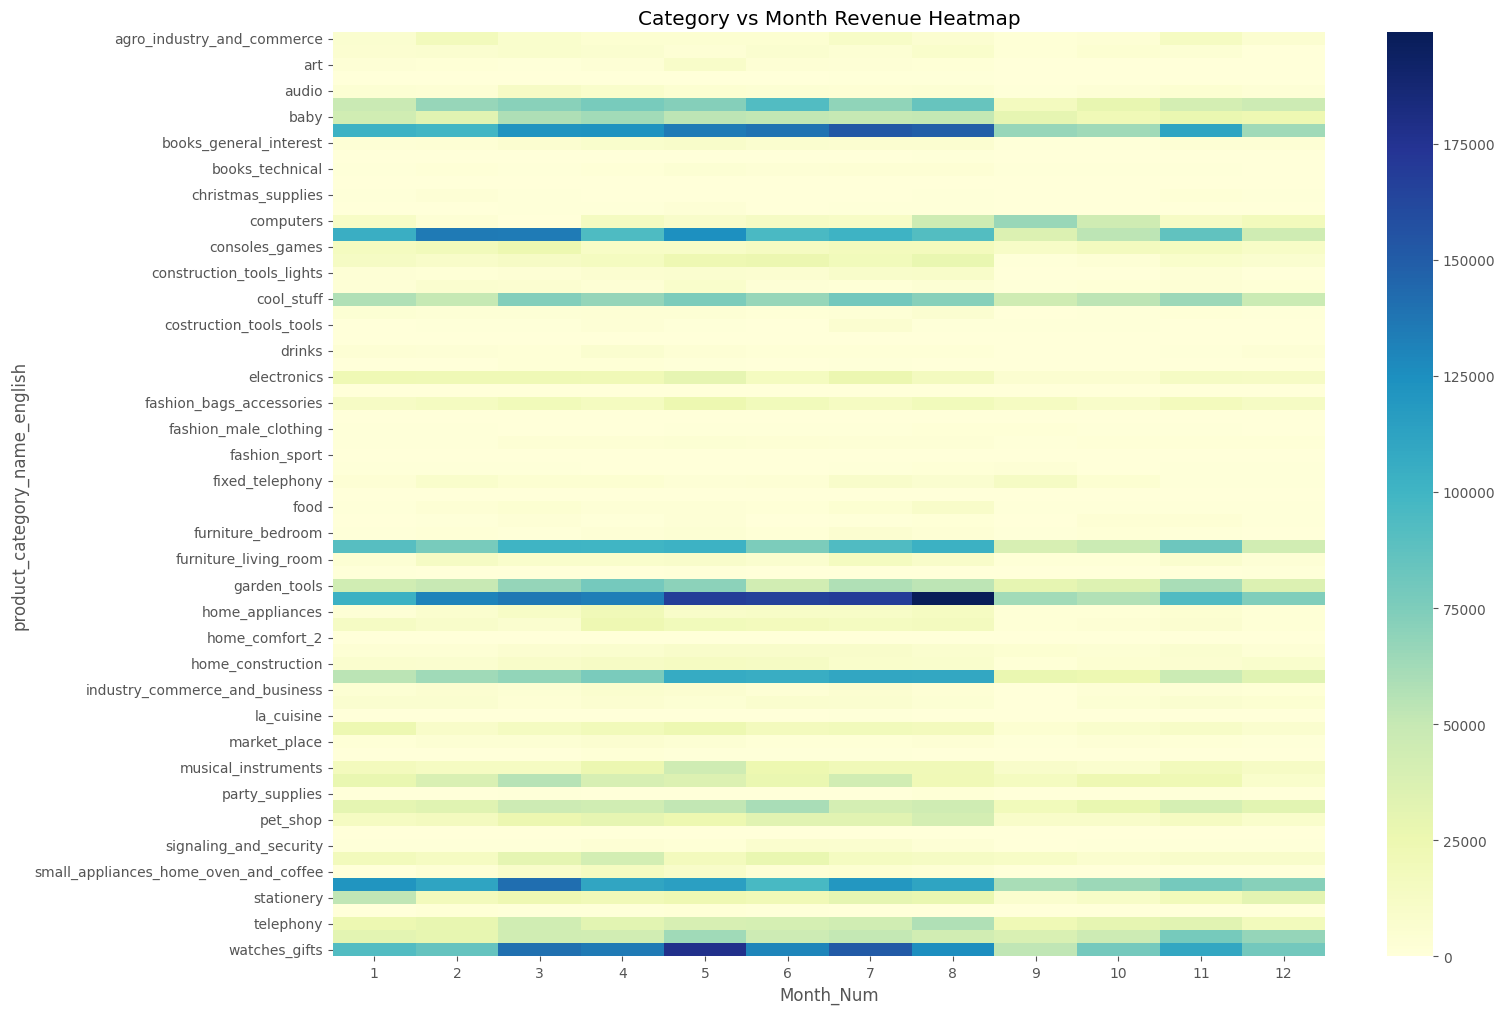

PROJECT COMPLETED SUCCESSFULLY


In [28]:
heatmap_data = pd.pivot_table(
    df,
    values='Revenue',
    index='product_category_name_english',
    columns='Month_Num',
    aggfunc='sum'
)

plt.figure(
    figsize=(16,12)
)

sns.heatmap(
    heatmap_data.fillna(0),
    cmap='YlGnBu'
)

plt.title(
    "Category vs Month Revenue Heatmap"
)

plt.show()

print("PROJECT COMPLETED SUCCESSFULLY")